In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

## #8_1 Kernel Density Estimators


In [50]:
data=[1,2,5,6,12,15,16,16,22,22,22,23]
space_array=np.linspace(0,30,1000)

In [ ]:
def kde_total(data,space,h=1.5):
    x_array=space
    kde_array=np.zeros_like(x_array)
    for i,x in enumerate(x_array):
        for xi in data:
            kde_array[i]+=kde_individual_box(x,xi,h)
    return normalize_kernel(kde_array)

def kde_individual_box(x,xi,h):# Parzen-Rosenblatt kernel
    #print(abs(x-xi),"greater than",h)
    if abs(x-xi)>h:
        return 0
    else:
        return 1



def kde_individual_gaussian(x,xi,sigma):# Gaussian kernel
    #print(abs(x-xi),"greater than",h)
    pdf_val=stats.norm.pdf(x,loc=xi,scale=sigma)
    return pdf_val
    
def kde_total_gaussian(data,space,sigma):
    x_array=space
    kde_array=np.zeros_like(x_array)
    for i,x in enumerate(x_array):
        for xi in data:
            kde_array[i]+=kde_individual_gaussian(x,xi,sigma)
    return normalize_kernel(kde_array)







def normalize_kernel(kde_array):
    sum_kde=np.sum(kde_array)
    return kde_array/sum_kde
    

Text(0.5, 1.0, 'KDE with box and gauss kernel')

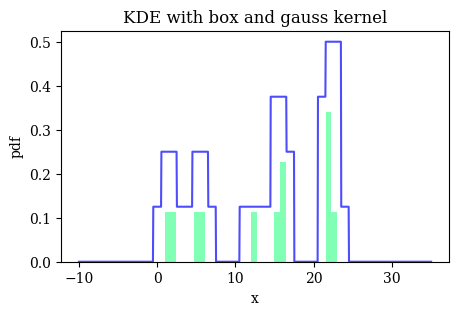

In [86]:

fig,ax=plt.subplots()
ax.hist(data,bins=30,density=True,label='histogram',color=my_cmap(0.5))
kde=kde_total(data=data,space=space_array,h=1.5)*100
ax.plot(space_array,kde,label='h=1.5',color=my_cmap(0.1))
ax.set_xlabel('x')
ax.set_ylabel('pdf')
ax.set_title('KDE with box and gauss kernel')

## #2 Gaussian Kernel

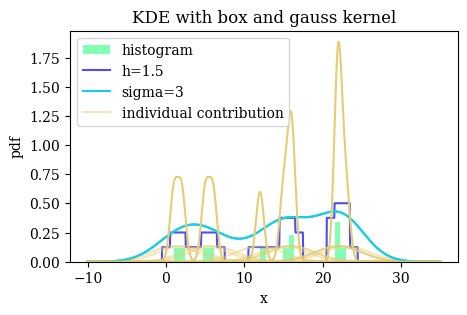

In [ ]:
sigma=3
space_array=np.linspace(-10,35,1000)
kde_gauss=kde_total_gaussian(data=data,space=space_array,sigma=sigma)*200
ax.plot(space_array,kde_gauss,label='sigma=3',color=my_cmap(0.3))

fig

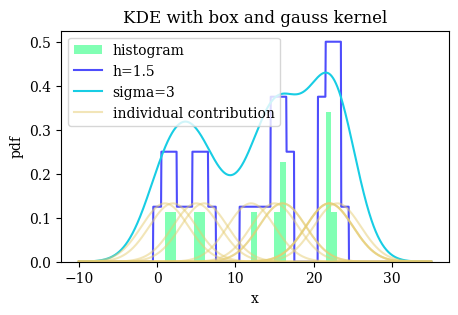

In [89]:
"""printing individual contributions for d in data"""

kde_individual=kde_individual_gaussian(x=space_array,xi=data[0],sigma=sigma)
ax.plot(space_array,kde_individual,color=my_cmap(0.7),alpha=0.5,label='individual contribution')

for d in data[1:]:
    kde_individual=kde_individual_gaussian(x=space_array,xi=d,sigma=sigma)
    ax.plot(space_array,kde_individual,color=my_cmap(0.7),alpha=0.5)

ax.legend()
fig

## #3 - Epanechnikov

In [93]:
def kde_individual_epan(x,xi):# Epanechnikov kernel
    #normalized to 1
    u=x-xi
    v=3/4*(1-u**2)
    if abs(u)>1:
        return 0
    else:
        return v
    
def kde_total_epan(data,space):
    x_array=space
    kde_array=np.zeros_like(x_array)
    for i,x in enumerate(x_array):
        for xi in data:
            kde_array[i]+=kde_individual_epan(x,xi)
    return kde_array/len(data)

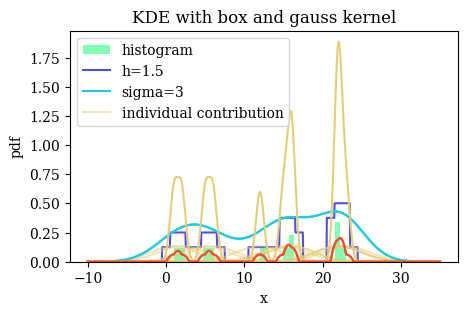

In [ ]:
kde_epan=kde_total_epan(data=data,space=space_array)
ax.plot(space_array,kde_epan,label='Epanechnikov',color=my_cmap(0.9))  


fig

In [99]:
x_compare=[6,10.1,20.499,20.501]

space_array=np.linspace(-10,35,1000)
kde_gauss=kde_total_gaussian(data=data,space=space_array,sigma=3)
kde_epan=kde_total_epan(data=data,space=space_array)
kde=kde_total(data=data,space=space_array,h=1.5)


print(f"x & KDE box & KDE gauss & KDE epan")

for x in x_compare:
    """finding the indices of the x_compare values in space_array"""
    idx = np.argmin(np.abs(space_array - x))
    print(f"{x:.3f} & {kde[idx]:.6f} &{kde_gauss[idx]:.6f} &{kde_epan[idx]:.6f}\\")

x & KDE box & KDE gauss & KDE epan
6.000 & 0.002506 &0.001379 &0.063616\
10.100 & 0.000000 &0.001016 &0.000000\
20.499 & 0.000000 &0.002100 &0.000000\
20.501 & 0.000000 &0.002100 &0.000000\
